In [1]:
#Import Libraries

#These libraries help us load data, evaluate models, and create graphs.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
import joblib

In [2]:
#Load Test Data

#Load the data that will be used to evaluate all models.

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

In [4]:
#Load Saved Models

#Load the trained Random Forest and XGBoost models.

rf_model = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')

In [7]:
# Retrain LR for comparison (or load if saved)
from sklearn.linear_model import LogisticRegression
X_train = pd.read_csv('../data/X_train_smote.csv')
y_train = pd.read_csv('../data/y_train_smote.csv').squeeze()

In [8]:
lr_model = LogisticRegression(max_iter=1000)

In [9]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

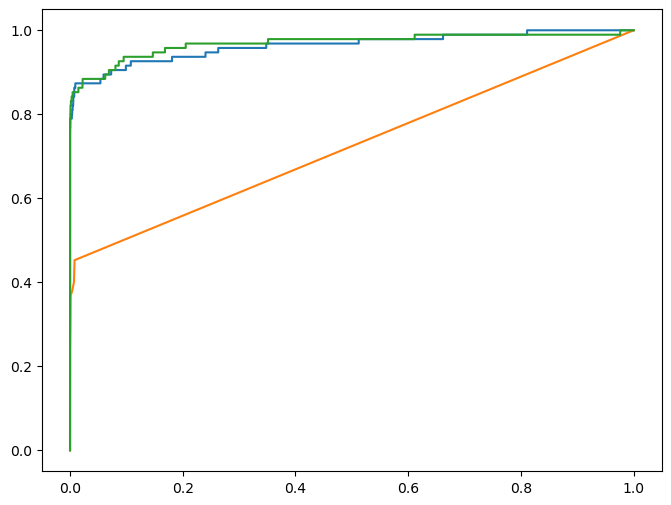

In [14]:
plt.figure(figsize=(8, 6))

results = {}

for name, model in models.items():

    # Predict probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate AUC
    auc = roc_auc_score(y_test, y_proba)

    # Calculate F1
    f1 = f1_score(y_test, model.predict(X_test))

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

    # Save scores
    results[name] = {
        "AUC": round(auc, 4),
        "F1": round(f1, 4)
    }

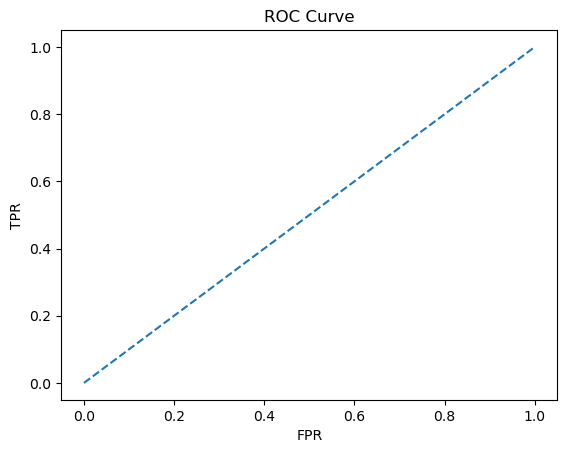

In [16]:
# Add random baseline
plt.plot([0, 1], [0, 1], '--')

# Labels and title
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")



# Show graph
plt.show()

In [17]:
# Create results table
results_df = pd.DataFrame(results).T

# Show results
print(results_df)

# Best model
print("Best Model:", results_df["AUC"].idxmax())

                        AUC      F1
Logistic Regression  0.9635  0.1015
Random Forest        0.7235  0.1731
XGBoost              0.9692  0.7812
Best Model: XGBoost


In [18]:
results_df.to_csv('../reports/model_comparison.csv')